In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
data = pd.read_csv('customer_churn.csv')

In [10]:
print(data.head())

print(data.describe())

print(data['Churn'].value_counts()) 

   CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0        1001       5            70.0         350.0  Month-to-month   
1        1002      10            85.5         850.5        Two year   
2        1003       3            55.3         165.9        One year   
3        1004       8            90.0         720.0  Month-to-month   
4        1005       2            65.2         130.4        One year   

      PaymentMethod  Churn  
0  Electronic check      1  
1      Mailed check      0  
2  Electronic check      1  
3       Credit card      0  
4  Electronic check      1  
        CustomerID     Tenure  MonthlyCharges  TotalCharges     Churn
count     5.000000   5.000000        5.000000      5.000000  5.000000
mean   1003.000000   5.600000       73.200000    443.360000  0.600000
std       1.581139   3.361547       14.389058    326.319158  0.547723
min    1001.000000   2.000000       55.300000    130.400000  0.000000
25%    1002.000000   3.000000       65.200000    

In [11]:
print("\nOriginal data shape:", data.shape)
print("Original 'is Churn' unique values:", data['Churn'].unique())



Original data shape: (5, 7)
Original 'is Churn' unique values: [1 0]


In [12]:
data = data.dropna()
print("Data shape after dropna:", data.shape)

Data shape after dropna: (5, 7)


In [13]:
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    if col != 'Churn':  # Assuming target is 'Churn'; adjust if different
        data[col] = le.fit_transform(data[col])

# Handle the target variable ('Churn')
# If already numeric/binary, convert to int
if data['Churn'].dtype in ['int64', 'float64'] and set(data['Churn'].dropna().unique()).issubset({0, 1}):
    print("Target is already binary. Converting to int.")
    data['Churn'] = data['Churn'].astype(int)
else:
    # Map based on actual values (update this dict after checking unique values above)
    # Examples: {'No': 0, 'Yes': 1} or {'False': 0, 'True': 1}
    mapping = {'No': 0, 'Yes': 1}  # Adjust based on your data's unique values!
    data['Churn'] = data['Churn'].map(mapping)
    
    # Drop rows where mapping failed (Churn is NaN)
    data = data.dropna(subset=['Churn'])
    data['Churn'] = data['Churn'].astype(int)

print("Data shape after target processing:", data.shape)
print("Target unique values after processing:", data['Churn'].unique())

# Final validation
if data.empty or data['Churn'].isna().sum() > 0 or not set(data['Churn'].unique()).issubset({0, 1}):
    raise ValueError("Dataset is empty or target is invalid. Check original unique values and adjust mapping.")

# Now separate features and target (after all drops)
features = data.drop('Churn', axis=1)
print("Features shape:", features.shape)
print("Target shape:", data['Churn'].shape)

# Handle infinities/large values in features
features.replace([np.inf, -np.inf], np.nan, inplace=True)
features.fillna(features.mean(), inplace=True)
features = np.clip(features, -1e10, 1e10)

# Feature scaling
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled = pd.DataFrame(features_scaled, columns=features.columns)



Target is already binary. Converting to int.
Data shape after target processing: (5, 7)
Target unique values after processing: [1 0]
Features shape: (5, 6)
Target shape: (5,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(features_scaled, data['Churn'], test_size=0.2, random_state=42)

In [15]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

In [16]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

Logistic Regression Accuracy: 0.0
Random Forest Accuracy: 0.0

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



C:\Users\Hiteash\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Hiteash\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Hiteash\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Hiteash\anaconda3\lib\site-packages\sklearn\metr

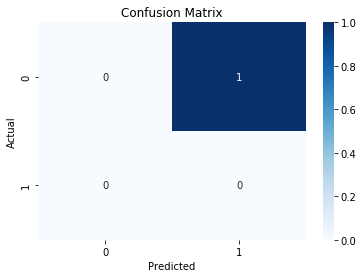

In [17]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()